In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py

from tqdm import trange
from tqdm import tqdm
from skimage.registration import phase_cross_correlation
from scipy.ndimage import shift

import brighteyes_ism.simulation.PSF_sim as sim
import brighteyes_ism.analysis.Graph_lib as gra
import brighteyes_ism.dataio.mcs as mcs

import brighteyes_flim.tools_phasor as flim
import brighteyes_flim.graph_tools as graph

from brighteyes_mcs_file import Alignment, calibrate_h5_file, show_h5_structure_html, sum_channel_applying_shifts

from s2ism import s2ism as s2
import s2ism.psf_estimator as est




/home/morlando1-iit.local/manuel/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters

In [2]:
FILE_REFERENCE = r'/home/morlando1-iit.local/manuel/18052026_flim/FLIMLabs.h5'
FILE_DATA      = r'/home/morlando1-iit.local/manuel/25052026_mito_tub_flim/25052026_tomm20_pxs100_0.h5'


DATA_KEY = "data" # usual input key: ('data', 'data_channels_extra')
CALIBRATION_PRODUCT = {"data": "spad", "data_channels_extra": "aux"}[DATA_KEY]
INSPECT_DATA_KEY = DATA_KEY

# ── Calibration parameters ─────────────────────────────────────────────────

TAU_REF              = 2.5
REFERENCE_TYPE       = "ref"
FIT_MODE             = "model_shift"
FIT_TYPE             = "likelihood"
LASER_FREQ_MHZ       = None
LASER_PERIOD_NS      = None
CHANNEL_SKEW_SOURCE  = "ref"
OVERWRITE            = True




## Calibration

In [3]:
FILE_WITH_CALIBRATION = calibrate_h5_file(
    FILE_DATA,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type=REFERENCE_TYPE,
    tau_ref=TAU_REF,
    fit_mode=FIT_MODE,
    fit_type=FIT_TYPE,
    channel_skew_type="phase_cross_correlation",
    channel_skew_source=CHANNEL_SKEW_SOURCE,
    channel_skew_fit_reference_channel=12,
    channel_skew_fit_upsampling=10,
    channel_skew_fit_apodize=False,
    period_ns=LASER_PERIOD_NS,
    overwrite=OVERWRITE,
)
print(FILE_WITH_CALIBRATION)



/home/morlando1-iit.local/manuel/25052026_mito_tub_flim/25052026_tomm20_pxs100_0_calib.h5


## Load Calibrated Data

In [4]:
with h5py.File(FILE_WITH_CALIBRATION, "r") as hf:
    calibration = hf[f"calibration/results/{CALIBRATION_PRODUCT}"]
    metadata = hf["raw/metadata"]

    laser_freq_mhz  = float(calibration.attrs["laser_frequency_mhz"])
    laser_period_ns = float(calibration.attrs["laser_period_ns"])
    nbin            = int(metadata.attrs["time_bins"])
    pixel_size_x_um = float(metadata.attrs["pixel_size_x_um"])
    pxdwelltime     = float(metadata.attrs["pixel_dwell_time_us"])

    # data_input shape: (rep, z, y, x, t_bins, channels)
    data_input                  = hf[f"raw/{CALIBRATION_PRODUCT}"][:]
    channel_skew                = calibration["timing/channel_skew_bins"][:]
    irf_common_delay_realigned  = calibration["aligned/irf_trace"][:]
    irf_from_fit = calibration["fit/irf_trace"][:]
    ref_common_delay_realigned  = calibration["aligned/reference_trace"][:]

dset = np.squeeze(data_input)  # (y, x, t_bins, channels)

print(f"Using calibrated laser timing: {laser_freq_mhz:.4f} MHz ({laser_period_ns:.4f} ns)")
print(f"data_input shape: {data_input.shape}  (rep, z, y, x, t_bins, channels)")




Using calibrated laser timing: 40.0000 MHz (25.0000 ns)
data_input shape: (1, 1, 512, 512, 91, 25)  (rep, z, y, x, t_bins, channels)


In [5]:
show_h5_structure_html(FILE_WITH_CALIBRATION)

'<div class="h5-tree">\n  <style>\n    .h5-tree {\n      color-scheme: light dark;\n      font-family: "Menlo", "Consolas", "DejaVu Sans Mono", monospace;\n      font-size: 13px;\n      line-height: 1.5;\n      color: var(--h5-fg);\n      --h5-fg: #1f2937;\n      --h5-muted: #6b7280;\n      --h5-border: #d1d5db;\n      --h5-group: #0f766e;\n      --h5-dataset: #1d4ed8;\n      --h5-attrs: #7c2d12;\n      --h5-node-ref: #7c3aed;\n      --h5-attr-key: #b45309;\n      --h5-attr-value: #374151;\n      --h5-root: #111827;\n    }\n    @media (prefers-color-scheme: dark) {\n      .h5-tree {\n        --h5-fg: #e5e7eb;\n        --h5-muted: #9ca3af;\n        --h5-border: #4b5563;\n        --h5-group: #5eead4;\n        --h5-dataset: #93c5fd;\n        --h5-attrs: #fdba74;\n        --h5-node-ref: #c4b5fd;\n        --h5-attr-key: #fbbf24;\n        --h5-attr-value: #f3f4f6;\n        --h5-root: #f9fafb;\n      }\n    }\n    .h5-tree ul {\n      list-style: none;\n            margin: 0.2rem 0 0.2rem 1.1

In [6]:
if False:
    irf_common_delay_realigned = Alignment.clean_irf_stack(
        irf_common_delay_realigned,
        threshold=0.3,
        window=2 / (laser_period_ns / nbin),
        time_axis=0,
        normalize=True,
    )

data_summed_no_alignment = np.sum(data_input, axis=(0, 1, 2, 3, 5))
irf_summed_no_alignment  = np.sum(irf_common_delay_realigned, axis=-1)

data_summed     = sum_channel_applying_shifts(data_input, channel_skew, axis=())[0, 0, ...]
irf_summed      = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=())
ref_summed      = sum_channel_applying_shifts(ref_common_delay_realigned, channel_skew, axis=())

print("data_summed:", data_summed.shape)
print("irf_summed:", irf_summed.shape)
print("ref_summed:", ref_summed.shape)



Summing shifted histogram chunks: 100%|██████████| 1/1 [00:00<00:00, 3495.25it/s]

data_summed: (512, 512, 91)
irf_summed: (91,)
ref_summed: (91,)


In [7]:
dt = laser_period_ns/nbin # DFD bin time, ns

print(f'Excitation frequency = {laser_freq_mhz:.2f} MHz')

time = np.arange(irf_common_delay_realigned.shape[0]) * dt

print(f"Time axis (ns): {time}")



Excitation frequency = 40.00 MHz
Time axis (ns): [ 0.          0.27472527  0.54945055  0.82417582  1.0989011   1.37362637
  1.64835165  1.92307692  2.1978022   2.47252747  2.74725275  3.02197802
  3.2967033   3.57142857  3.84615385  4.12087912  4.3956044   4.67032967
  4.94505495  5.21978022  5.49450549  5.76923077  6.04395604  6.31868132
  6.59340659  6.86813187  7.14285714  7.41758242  7.69230769  7.96703297
  8.24175824  8.51648352  8.79120879  9.06593407  9.34065934  9.61538462
  9.89010989 10.16483516 10.43956044 10.71428571 10.98901099 11.26373626
 11.53846154 11.81318681 12.08791209 12.36263736 12.63736264 12.91208791
 13.18681319 13.46153846 13.73626374 14.01098901 14.28571429 14.56043956
 14.83516484 15.10989011 15.38461538 15.65934066 15.93406593 16.20879121
 16.48351648 16.75824176 17.03296703 17.30769231 17.58241758 17.85714286
 18.13186813 18.40659341 18.68131868 18.95604396 19.23076923 19.50549451
 19.78021978 20.05494505 20.32967033 20.6043956  20.87912088 21.15384615
 2

In [8]:
import torch 

def pad_tensor(x: torch.Tensor, pad_left: int, pad_right: int, dim: int, mode: str = "reflect"):
    """
    Pad a tensor along one dimension.

    Args:
        x (torch.Tensor): Input tensor to pad.
        pad_left (int): Number of elements to pad before the data along the specified dimension.
        pad_right (int): Number of elements to pad after the data along the specified dimension.
        dim (int): Dimension along which to pad.
        mode (str, optional): Padding mode. One of {"reflect", "replicate", "constant"}. Default is "reflect".

    Returns:
        torch.Tensor: Padded tensor with the same dtype and device as input.

    Raises:
        ValueError: If an unsupported padding mode is specified.
    """

    if pad_left == 0 and pad_right == 0:
        return x

    length = x.shape[dim]

    if mode == "reflect":
        left_idx = torch.arange(pad_left, 0, -1, device=x.device)
        right_idx = torch.arange(length - 2, length - pad_right - 2, -1, device=x.device)
    elif mode == "replicate":
        left_idx = torch.zeros(pad_left, dtype=torch.long, device=x.device)
        right_idx = torch.full((pad_right,), length - 1, dtype=torch.long, device=x.device)
    elif mode == "constant":
        pad_shape = list(x.shape)
        pad_shape[dim] = pad_left + pad_right
        constant_pad = torch.zeros(pad_shape, dtype=x.dtype, device=x.device)
        return torch.cat([constant_pad.narrow(dim, 0, pad_left),
                          x,
                          constant_pad.narrow(dim, pad_left, pad_right)], dim=dim)
    else:
        raise ValueError(f"Unsupported padding mode: {mode}")

    # Select slices
    pad_left_tensor = x.index_select(dim, left_idx)
    pad_right_tensor = x.index_select(dim, right_idx)

    return torch.cat([pad_left_tensor, x, pad_right_tensor], dim=dim)


def median_filter(x: torch.Tensor, window_size=3, dims=None, mode="reflect"):
    """
    Apply an N-dimensional median filter over user-specified dimensions.

    Args:
        x (torch.Tensor): Input tensor of any shape.
        window_size (int or list/tuple of ints, optional): Window size(s) for the filter. If int, same size for all dims. If list/tuple, must match len(dims). Default is 3.
        dims (list/tuple of ints, optional): Dimensions to filter along. If None, all dimensions are filtered. Default is None.
        mode (str, optional): Padding mode. One of {"reflect", "replicate", "constant"}. Default is "reflect".

    Returns:
        torch.Tensor: Median-filtered tensor of the same shape as x.

    Raises:
        ValueError: If window_size is not odd or does not match dims length.
    """

    if dims is None:
        dims = list(range(x.ndim))

    if isinstance(window_size, int):
        window_size = [window_size] * len(dims)
    elif len(window_size) != len(dims):
        raise ValueError("window_size must be scalar or match len(dims)")

    # check for odd values
    for w in window_size:
        if w % 2 == 0:
            raise ValueError(f"All window sizes must be odd, got {w}")

    out = x
    for d, w in zip(dims, window_size):
        pad_left = (w - 1) // 2
        pad_right = w // 2

        # Pad along dimension
        out = pad_tensor(out, pad_left, pad_right, d, mode=mode)

        # Unfold and compute median
        out = out.unfold(d, w, 1).median(dim=-1).values

    return out

In [9]:
irf_common_delay_realigned_smoothed = median_filter(torch.tensor(irf_common_delay_realigned), window_size=5, dims=[0], mode='replicate')  

Text(0.5, 1.0, 'Smoothed Impulse Response Functions')

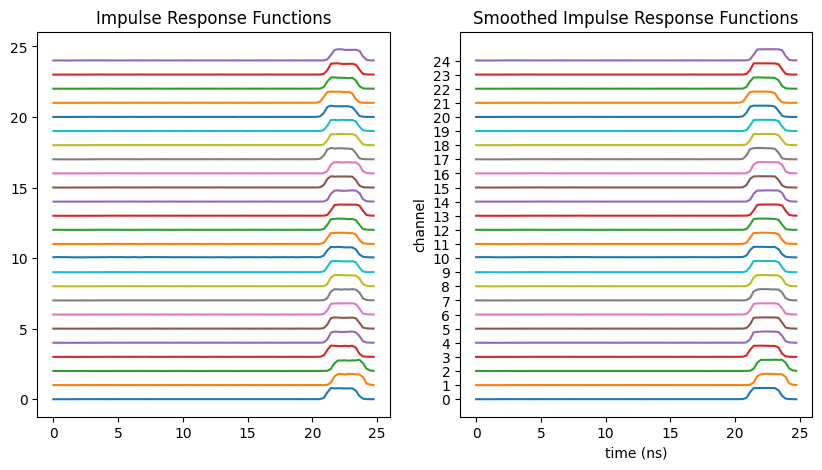

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for n in range(dset.shape[-1]):
    irf_n = irf_common_delay_realigned[:, n]
    irf_norm = irf_n / (irf_n.max() + 1e-10)  # normalizza a [0, 1]

    irf_n_smoothed = irf_common_delay_realigned_smoothed[:, n]
    irf_norm_smoothed = irf_n_smoothed / (irf_n_smoothed.max() + 1e-10)  # normalizza a [0, 1]
    ax[0].plot(time, 0.8 * irf_norm + n)
    ax[1].plot(time, 0.8 * irf_norm_smoothed + n)


plt.yticks(np.arange(25))
plt.xlabel('time (ns)')
plt.ylabel('channel')
ax[0].set_title('Impulse Response Functions')
ax[1].set_title('Smoothed Impulse Response Functions')



# FLISM image reconstruction

## s2ISM

We simulate the spatial PSFs of the system.

In [11]:
exPar = sim.simSettings()
exPar.na = 1.4   # numerical aperture
exPar.wl = 488   # excitation wavelength [nm]
exPar.gamma = 45  # parameter describing the light polarization
exPar.beta = 90  # parameter describing the light polarization
exPar.n = 1.5 # refractive index
exPar.mask_sampl = 100 # pupile plane sample points

emPar = exPar.copy()
emPar.wl = 500 # emission wavelength [nm]

grid = sim.GridParameters()
grid.Nz = 2 # number of axial planes
grid.pxsizex = pixel_size_x_um*1e3 # pixel size [nm]
grid.pxsizez = 720 # axial spacing [nm]
grid.pxpitch = 75e3 # pitch of the detector array [nm]
grid.pxdim = 50e3 # size of the pixels of the detector array [nm]
grid.N = 5 # numer of pixels per axis of the array

psf_spatial, _,_ = est.psf_estimator_from_data(dset.sum(-2), exPar, emPar, grid, z_out_of_focus = grid.pxsizez)



pxsizex       97.85
pxsizez       720.00
Nx            100.00
Nz            2.00
pxpitch       75000.00
pxdim         50000.00
pinhole_shape square
geometry      rect
N             5.00
M             552.00
rotation      3.17
mirroring     1.00
name          
shift         63.64


Out-of-focus PSFs


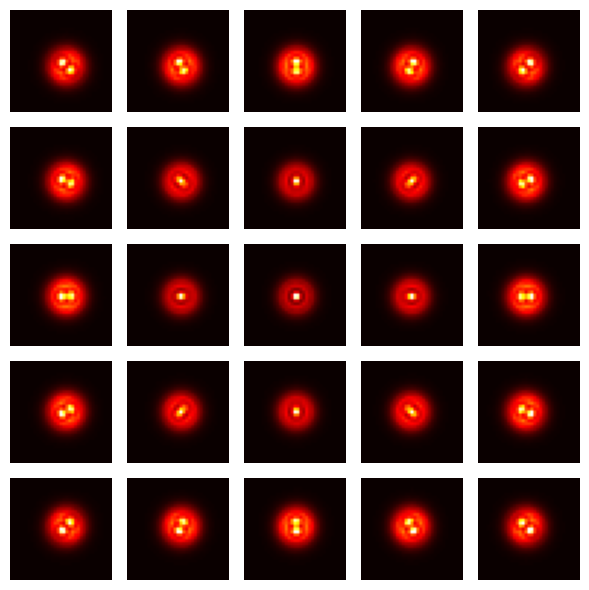

In [12]:
print('Out-of-focus PSFs')
fig_1 = gra.ShowDataset(psf_spatial[0])



In-focus PSFs


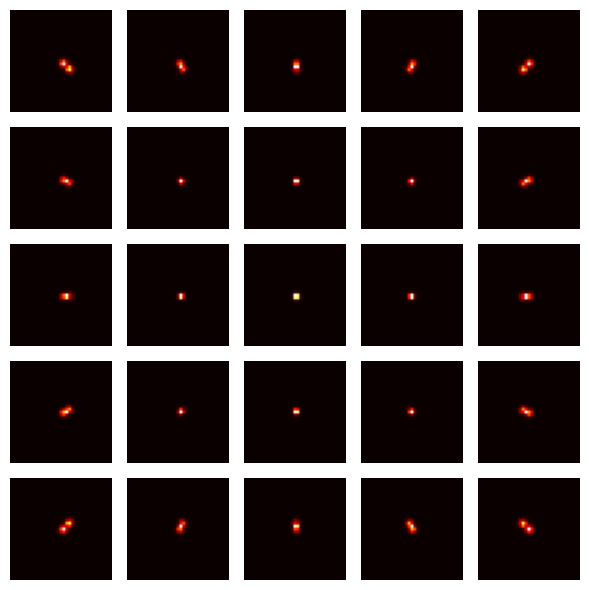

In [13]:
print('In-focus PSFs')
fig_2 = gra.ShowDataset(psf_spatial[1])



We merge the temporal IRFs with the spatial PSFs in a single 4D convolution kernel.

In [14]:
psf_irf = est.combine_psf_irf(psf_spatial, irf_common_delay_realigned)

In [15]:
psf_irf_smoothed = est.combine_psf_irf(psf_spatial, irf_common_delay_realigned_smoothed)

In [16]:
delta_irf=np.zeros_like(irf_common_delay_realigned)
delta_irf[nbin//2, :] = 1

psf_delta = est.combine_psf_irf(psf_spatial, delta_irf)

In [17]:
shift_to_center = np.argmax(irf_common_delay_realigned.sum(axis=-1)) - irf_common_delay_realigned.shape[0]//2
irf_common_delay_centrata = np.roll(irf_common_delay_realigned, -shift_to_center, axis=0)
psf_irf_centrata = est.combine_psf_irf(psf_spatial, irf_common_delay_centrata)

We launch the reconstruction. Since the raw data require a significant amount of memory, we split the reconstruction into multiple batches. The overlap should be a number of pixels much larger than the size of the PSF, to avoid stitching artefacts.

If CUDA is available, choose _process='gpu'_ to speed up the computation.

In [18]:
s2_rec_no_IRF = s2.batch_reconstruction(dset, psf_delta, batch_size = [301, 301], overlap = 40, max_iter = 5, process='cpu')
s2_flism_no_IRF = s2_rec_no_IRF[1]

Batch 1/4


Progress: 6it [00:48,  8.03s/it]                       


Batch 2/4


Progress: 6it [00:40,  6.68s/it]                       


Batch 3/4


Progress: 6it [00:39,  6.66s/it]                       


Batch 4/4


Progress: 6it [00:33,  5.52s/it]                       


In [ ]:
s2_rec = s2.batch_reconstruction(dset, psf_irf, batch_size = [301, 301], overlap = 40, max_iter = 7, process='gpu')
s2_flism = s2_rec[1]

Batch 1/4


Progress: 8it [01:04,  8.09s/it]                       


Batch 2/4


Progress: 8it [00:53,  6.72s/it]                       


Batch 3/4


Progress: 8it [00:52,  6.62s/it]                       


Batch 4/4


Progress: 8it [00:43,  5.47s/it]                       


Text(0.5, 1.0, 's$^2$ISM')

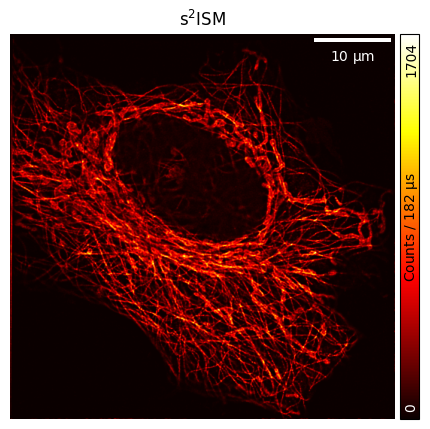

In [20]:
intensity_map = s2_flism.sum(-1)

fig, ax = plt.subplots(figsize = (15,5))

gra.ShowImg(intensity_map, pixel_size_x_um, pxdwelltime, fig = fig, ax = ax)
ax.set_title(r's$^2$ISM')



Text(0.5, 1.0, 'Confronto IRF — Raw — s²ISM ricostruito')

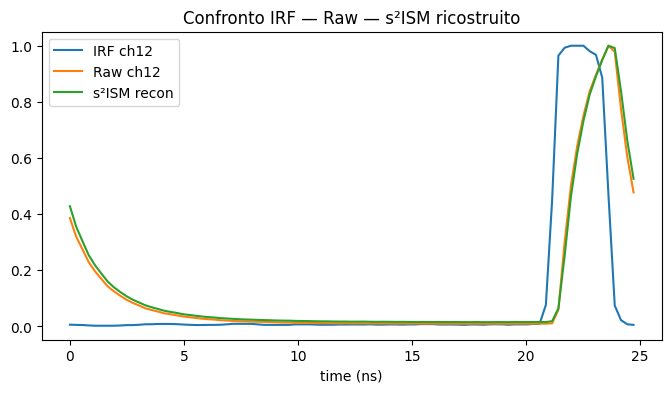

In [ ]:
ch = 12

irf_ch    = irf_common_delay_realigned[:, ch]
raw_ch    = dset[:, :, :, ch].sum(axis=(0, 1))   # somma su x,y
recon_ch  = s2_flism.sum(axis=(0, 1))             # s2_flism non ha asse canale
recon_ch_no_IRF = s2_flism_no_IRF.sum(axis=(0, 1)) # s2_flism_no_IRF non ha asse canale

# normalizza a 1 per confrontare le forme
def norm(x): return x / x.max()

plt.figure(figsize=(8, 4))
plt.plot(time, norm(irf_ch),   label='IRF ch12')
# plt.plot(time, irf_from_fit[:,12], label='IRF from fit')
plt.plot(time, norm(raw_ch),   label='Raw ch12')
plt.plot(time, norm(recon_ch_no_IRF), label='s²ISM recon')
plt.xlabel('time (ns)')
plt.legend()
plt.title('Confronto IRF — Raw — s²ISM ricostruito')


# Phasor analysis

In [ ]:
# Direct phasor on s²ISM — already deconvolved from the IRF.
irf_phasor      = flim.calculate_phasor(irf_summed, threshold=0, harmonic=1)
ref_phasor      = flim.calculate_phasor(ref_summed, threshold=0, harmonic=1)

dato = s2_flism_no_IRF
s2_phasor_pix = flim.calculate_phasor(dato, harmonic=1)


intensity_map = dato.sum(axis=-1)

In [ ]:
# usare questa correzione di fare se nella deconvoluzione si considera solo la PSF (considero anche l'irf, ma al posto della irf reale sto usando una delta), 
# quindi bisogna poi calibrare anche per l'IRF (o equivalentemente per la ref)

# Theoretical phasor of the monoexponential reference sample
omega = 2 * np.pi * laser_freq_mhz * 1e6          # rad/s
tau_ref_s = TAU_REF * 1e-9                          # ns → s
ref_phasor_theoretical = 1.0 / (1.0 - 1j * omega * tau_ref_s)

# The system response = measured_ref / theoretical_ref
correction = ref_phasor / ref_phasor_theoretical
phasor_map_corrected  = s2_phasor_pix / correction

In [ ]:
#usare questa correzione di fare se nella deconvoluzione si considera sia la PSF che l'irf
#phasor_map_corrected  = phasor_map * np.exp(1j * -np.pi)

In [ ]:
tau_m_map   = flim.calculate_tau_m(phasor_map_corrected,   dfd_freq=laser_freq_mhz * 1e6) * 1e9
tau_phi_map = flim.calculate_tau_phi(phasor_map_corrected, dfd_freq=laser_freq_mhz * 1e6) * 1e9
lifetime_map = tau_m_map

threshold = 0.05
thresholded_phasor_map    = flim.threshold_phasor(intensity_map, phasor_map_corrected, threshold)
thresholded_intensity_map = flim.threshold_intensity(intensity_map, threshold)
thresholded_tau_map, _, lifetime_mask = graph.threshold_lifetime_map(
    lifetime_map, intensity=intensity_map, threshold=threshold,
)

print(f"\nValid pixels after threshold: {np.sum(lifetime_mask)}")



Valid pixels after threshold: 102682


/home/morlando1-iit.local/manuel/BrightEyes-Flim/src/brighteyes_flim/tools_phasor.py:603: RuntimeWarning: invalid value encountered in sqrt
  tau_m = np.sqrt((1. / (m ** 2)) - 1) / (2 * np.pi * dfd_freq)


Text(0.5, 1.0, 'Phasor — s$^2$ISM (corrected)')

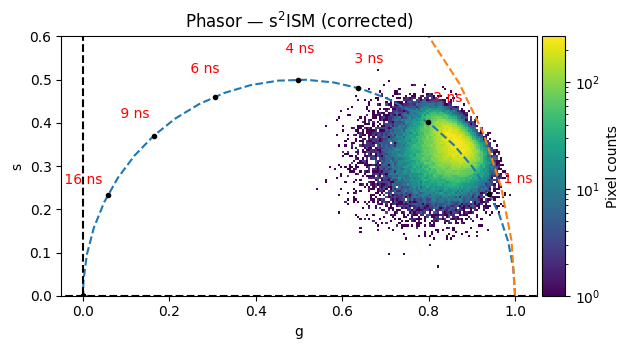

In [50]:
fig, ax = flim.plot_phasor(
    thresholded_phasor_map,
    quadrant="first",
    bins_2dplot=400,
    cmap="viridis",
    dfd_freq=laser_freq_mhz * 1e6,
)
ax.set_title(r"Phasor — s$^2$ISM (corrected)")



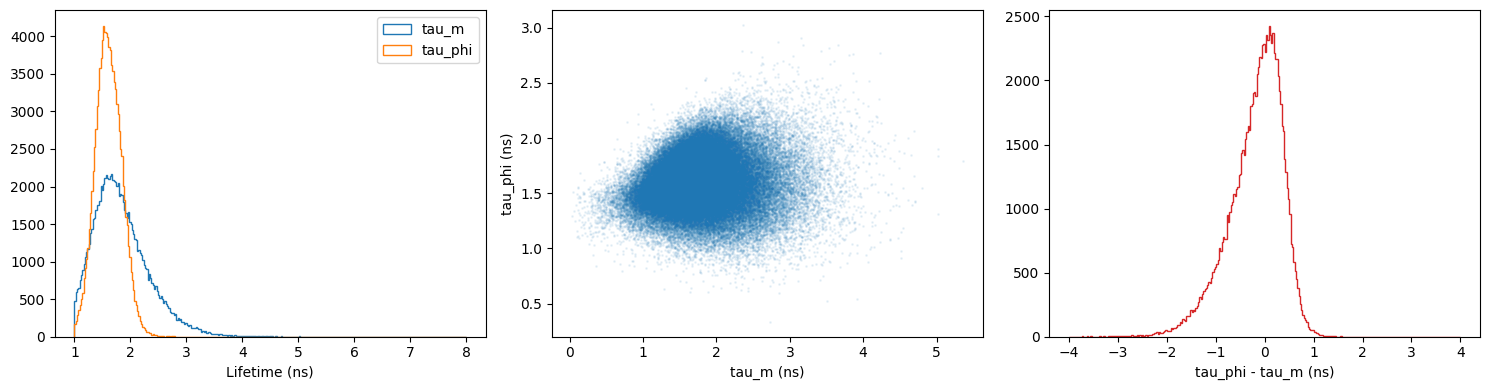

In [48]:
tau_compare_mask = (
    np.isfinite(tau_m_map)
    & np.isfinite(tau_phi_map)
    & np.isfinite(intensity_map)
    & (intensity_map > threshold * np.nanmax(intensity_map))
)

tau_m_compare   = tau_m_map[tau_compare_mask]
tau_phi_compare = tau_phi_map[tau_compare_mask]
tau_diff_compare = tau_phi_compare - tau_m_compare

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].hist(tau_m_compare,   bins=300, range=(1, 8), histtype="step", label="tau_m")
axs[0].hist(tau_phi_compare, bins=300, range=(1, 8), histtype="step", label="tau_phi")
axs[0].set_xlabel("Lifetime (ns)")
axs[0].legend()
axs[1].scatter(tau_m_compare, tau_phi_compare, s=1, alpha=0.08)
axs[1].set_xlabel("tau_m (ns)")
axs[1].set_ylabel("tau_phi (ns)")
axs[2].hist(tau_diff_compare, bins=300, range=(-4, 4), histtype="step", color="tab:red")
axs[2].set_xlabel("tau_phi - tau_m (ns)")
fig.tight_layout()



(<Figure size 1300x600 with 3 Axes>,
 (<Axes: title={'center': 'Lifetime map'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

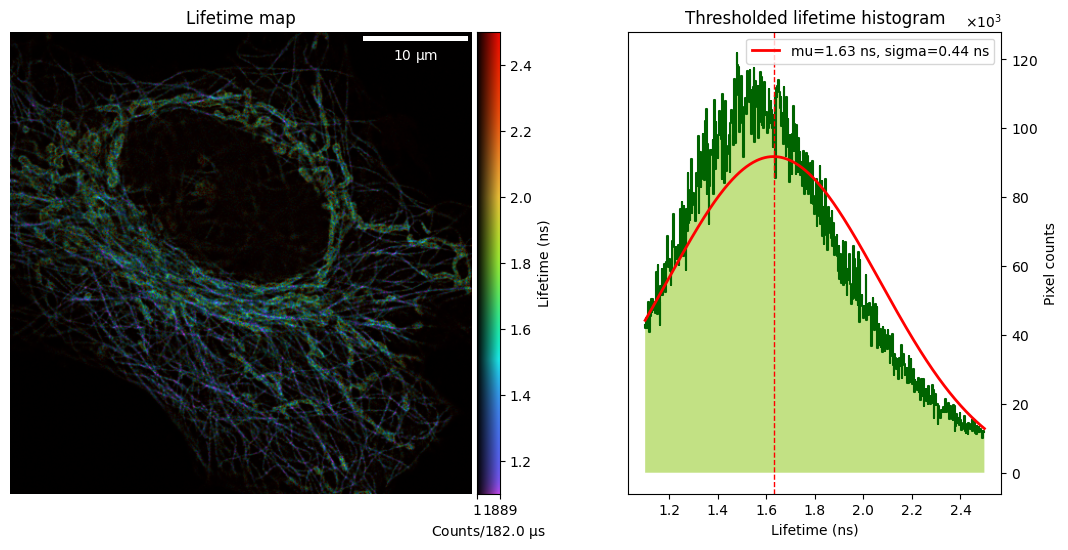

In [51]:
graph.plot_lifetime_summary(
    intensity=intensity_map,
    lifetime=lifetime_map,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[1.1, 2.5],
    crop=30,
    threshold=threshold,
    bins=500,
    colormap="turbo",
    weighted_histogram=True,
)

